# Basin08 Topology Sanity Checks

Exploratory notebook for understanding the upstream/downstream structure of the `basin08` table.

**Key fields:**
- `hybas_id` — basin identifier (float, use as int)
- `next_down` — immediate downstream basin (`0` = terminal outlet)
- `next_sink` — terminal outlet basin for this drainage system (macro-watershed key)
- `main_bas` — main river basin grouping
- `dist_sink` — cumulative flow distance to terminal outlet (km)
- `dist_main` — distance to main stem (km)
- `sub_area` — sub-basin area (km²)
- `up_area` — total upstream contributing area (km²)
- `endo` — endorheic flag (drains to interior, not ocean)
- `order_` — Strahler stream order

**Traversal note:** use `next_down` for upstream/downstream navigation, NOT `next_sink`.
`next_sink` is a partition key identifying which terminal outlet a basin belongs to.

**Distance proxy:** `dist_sink` difference between two basins in the same watershed
approximates metric flow distance without needing HydroRIVERS.

In [ ]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', message='pandas only supports SQLAlchemy')

sys.path.insert(0, str(Path('..', '..').resolve()))
from scripts.shared.db_utils import db_connect

conn = db_connect()
print('Connected')

In [ ]:
# ── Helper functions ──────────────────────────────────────────────────────────

def find_basin(conn, lon, lat):
    """Find the basin08 row whose polygon contains the point (strict containment).
    May return a small floodplain or delta sub-basin rather than the main channel."""
    row = conn.execute("""
        SELECT id, hybas_id, next_down, next_sink, dist_sink, sub_area, up_area,
               endo, order_, main_bas
        FROM basin08
        WHERE ST_Covers(geom, ST_SetSRID(ST_MakePoint(%s, %s), 4326))
        LIMIT 1
    """, (lon, lat)).fetchone()
    return row


def find_main_basin(conn, lon, lat, radius_deg=0.25):
    """Find the most hydrologically significant basin near a point.

    Searches within radius_deg and returns the basin with the largest upstream
    contributing area. More robust than strict containment for floodplains and
    deltas where the containing polygon may be a small local sub-basin.
    """
    row = conn.execute("""
        SELECT id, hybas_id, next_down, next_sink, dist_sink, sub_area, up_area,
               endo, order_, main_bas
        FROM basin08
        WHERE ST_DWithin(
            geom,
            ST_SetSRID(ST_MakePoint(%s, %s), 4326),
            %s
        )
        ORDER BY up_area DESC
        LIMIT 1
    """, (lon, lat, radius_deg)).fetchone()
    return row


def get_upstream_catchment(conn, hybas_id, max_depth=None):
    """Retrieve all non-endorheic basins upstream of hybas_id via next_down traversal.

    Endorheic basins (endo != 0) are excluded: they have dist_sink=0 and are
    their own next_sink, so they corrupt distance calculations if included.

    Returns DataFrame with depth (hops) and derived flow distance (km).
    """
    depth_clause = f"AND u.depth < {max_depth}" if max_depth else ""
    sql = f"""
        WITH RECURSIVE upstream AS (
            SELECT hybas_id, next_down, next_sink, dist_sink,
                   sub_area, up_area, endo,
                   tmp_dc_syr, pre_mm_syr, ari_ix_sav,
                   tmp_dc_uyr, pre_mm_uyr, ari_ix_uav,
                   0 AS depth
            FROM basin08
            WHERE hybas_id = %(target)s
              AND endo = 0
            UNION ALL
            SELECT b.hybas_id, b.next_down, b.next_sink, b.dist_sink,
                   b.sub_area, b.up_area, b.endo,
                   b.tmp_dc_syr, b.pre_mm_syr, b.ari_ix_sav,
                   b.tmp_dc_uyr, b.pre_mm_uyr, b.ari_ix_uav,
                   u.depth + 1
            FROM basin08 b
            JOIN upstream u ON b.next_down = u.hybas_id
            WHERE b.endo = 0
            {depth_clause}
        )
        SELECT *,
               dist_sink - (SELECT dist_sink FROM basin08 WHERE hybas_id = %(target)s)
                   AS flow_dist_upstream_km
        FROM upstream
        ORDER BY depth, hybas_id
    """
    return pd.read_sql(sql, conn, params={'target': hybas_id})


def weighted_sig(df, weight_col, sig_col):
    """Weighted mean of a signature field."""
    w = df[weight_col]
    v = df[sig_col].astype(float)
    mask = v.notna() & w.notna() & (w > 0)
    return np.average(v[mask], weights=w[mask])


print('Helper functions defined.')

## 1. Basic counts and topology structure

In [3]:
summary = pd.read_sql("""
    SELECT
        COUNT(*)                                    AS total_basins,
        COUNT(DISTINCT next_sink)                   AS macro_watersheds,
        COUNT(*) FILTER (WHERE next_down = 0)       AS terminal_basins,
        COUNT(*) FILTER (WHERE endo = 1)            AS endorheic,
        COUNT(*) FILTER (WHERE coast = 1)           AS coastal,
        ROUND(MIN(dist_sink)::numeric, 1)           AS min_dist_sink_km,
        ROUND(MAX(dist_sink)::numeric, 1)           AS max_dist_sink_km,
        ROUND(AVG(dist_sink)::numeric, 1)           AS avg_dist_sink_km,
        ROUND(MIN(sub_area)::numeric, 2)            AS min_basin_km2,
        ROUND(MAX(sub_area)::numeric, 0)            AS max_basin_km2,
        ROUND(AVG(sub_area)::numeric, 0)            AS avg_basin_km2
    FROM basin08
""", conn)
summary.T

,0
total_basins,190675.0
macro_watersheds,26099.0
terminal_basins,23996.0
endorheic,31021.0
coastal,9615.0
min_dist_sink_km,0.0
max_dist_sink_km,6786.4
avg_dist_sink_km,1066.8
min_basin_km2,0.0
max_basin_km2,115570.0


In [4]:
# Largest macro-watersheds by upstream area of their terminal basin
top_watersheds = pd.read_sql("""
    SELECT
        next_sink,
        COUNT(*)                          AS basin_count,
        ROUND(MAX(up_area)::numeric, 0)   AS total_up_area_km2,
        ROUND(MAX(dist_sink)::numeric, 0) AS max_dist_sink_km,
        MAX(endo)                         AS has_endorheic
    FROM basin08
    GROUP BY next_sink
    ORDER BY total_up_area_km2 DESC
    LIMIT 20
""", conn)
top_watersheds

,next_sink,basin_count,total_up_area_km2,max_dist_sink_km,has_endorheic
0,6.080007e+09,7024,5912761.0,5915.0,0
1,1.080020e+09,5033,3705302.0,4913.0,0
2,7.080047e+09,4578,3179500.0,5970.0,0
3,1.080034e+09,4142,2916808.0,6786.0,0
4,6.080017e+09,3506,2594298.0,3747.0,0
5,3.080005e+09,3515,2489752.0,5204.0,0
6,3.080002e+09,3445,2467589.0,5418.0,0
7,3.080009e+09,3564,2453575.0,4945.0,0
8,1.080022e+09,3061,2098664.0,4202.0,0
9,4.080001e+09,2884,1998203.0,4790.0,0


## 2. Find a known point's basin

Test locations — well-known river systems with clear environmental expectations:

| Place | Lon | Lat | Expected system |
|---|---|---|---|
| Ur (ancient, near Tigris-Euphrates mouth) | 46.10 | 30.96 | Tigris-Euphrates |
| Cairo (Nile Delta) | 31.24 | 30.05 | Nile |
| Harappa (Indus Valley) | 72.86 | 30.63 | Indus |
| Manaus (Amazon confluence) | -60.02 | -3.10 | Amazon |
| Timbuktu (Niger inland delta) | -3.01 | 16.77 | Niger |

Two methods compared:
- **contains**: strict point-in-polygon (may find a small floodplain sub-basin)
- **max_uparea**: largest `up_area` within 0.25° radius (targets the main channel)

In [ ]:
TEST_PLACES = {
    'Ur (Tigris-Euphrates)':  (46.10,  30.96),
    'Cairo (Nile)':           (31.24,  30.05),
    'Harappa (Indus)':        (72.86,  30.63),
    'Manaus (Amazon)':        (-60.02, -3.10),
    'Timbuktu (Niger)':       (-3.01,  16.77),
}

def _row_to_dict(place, method, r):
    if r:
        return {
            'place': place, 'method': method,
            'hybas_id': int(r[1]), 'next_sink': int(r[3]),
            'dist_sink_km': round(r[4], 1),
            'sub_area_km2': round(r[5], 0),
            'up_area_km2':  round(r[6], 0),
            'order': r[8],
        }
    return {'place': place, 'method': method, 'hybas_id': None}

rows = []
for place, (lon, lat) in TEST_PLACES.items():
    rows.append(_row_to_dict(place, 'contains',   find_basin(conn, lon, lat)))
    rows.append(_row_to_dict(place, 'max_uparea', find_main_basin(conn, lon, lat)))

results_df = pd.DataFrame(rows).set_index(['place', 'method'])
print(results_df.to_string())

In [6]:
print(results_df.to_string())

                                    hybas_id   next_sink  dist_sink_km  sub_area_km2  up_area_km2  order
place                 method                                                                            
Ur (Tigris-Euphrates) contains    2080815450  2080073570         342.1         984.0       9483.0      2
                      max_uparea  2080818060  2080073570         261.8         978.0     456772.0      1
Cairo (Nile)          contains    1080149880  1080034260         144.6        2681.0    2914060.0      1
                      max_uparea  1080149880  1080034260         144.6        2681.0    2914060.0      1
Harappa (Indus)       contains    4080745880  4080033640        1409.1        1416.0       1416.0      5
                      max_uparea  4080746170  4080033640        1307.7        1089.0      31172.0      4
Manaus (Amazon)       contains    6080279940  6080007000        1340.9         109.0        109.0      3
                      max_uparea  6080278540  608000700

## 3. Upstream catchment traversal

Recursive CTE: traverse `next_down` links *upward* from a target basin.
Each upstream basin has a `depth` (hops from the pour point); flow distance
is derived from `dist_sink` differences.

We use the `max_uparea` result for Ur — more likely to be the main channel basin.

In [7]:
# Anchor basin for Section 3 onward
ur_hybas    = int(results_df.loc[('Ur (Tigris-Euphrates)', 'max_uparea'), 'hybas_id'])
ur_up_area  = results_df.loc[('Ur (Tigris-Euphrates)', 'max_uparea'), 'up_area_km2']
ur_dist_sink = results_df.loc[('Ur (Tigris-Euphrates)', 'max_uparea'), 'dist_sink_km']
ur_next_sink = int(results_df.loc[('Ur (Tigris-Euphrates)', 'max_uparea'), 'next_sink'])

print(f"Ur basin hybas_id (max_uparea method): {ur_hybas}")
print(f"up_area (full upstream contributing area): {ur_up_area:,.0f} km\u00b2")
print(f"dist_sink (distance to ocean): {ur_dist_sink} km")

Ur basin hybas_id (max_uparea method): 2080818060
up_area (full upstream contributing area): 456,772 km²
dist_sink (distance to ocean): 261.8 km


In [8]:
# Full upstream catchment for Ur — may take a moment for large watersheds
ur_upstream = get_upstream_catchment(conn, ur_hybas)
print(f"Total upstream basins: {len(ur_upstream):,}")
print(f"Max depth (hops): {ur_upstream['depth'].max()}")
print(f"Max flow dist upstream (km): {ur_upstream['flow_dist_upstream_km'].max():.1f}")
ur_upstream[['hybas_id','depth','dist_sink','flow_dist_upstream_km',
             'sub_area','up_area','endo']].head(10)

,hybas_id,depth,dist_sink,flow_dist_upstream_km,sub_area,up_area,endo
0,2.080818e+09,0,261.8,0.0,977.6,456772.1,0
1,2.080818e+09,1,309.2,47.4,431.6,18019.7,0
2,2.080818e+09,1,309.2,47.4,50.1,437774.1,0
3,2.080812e+09,2,347.2,85.4,992.1,16544.0,0
4,2.080812e+09,2,347.0,85.2,1044.3,1044.4,0
5,2.080817e+09,2,318.1,56.3,467.1,13825.4,0
6,2.080817e+09,2,317.9,56.1,339.9,423898.6,0
7,2.080806e+09,3,397.9,136.1,119.8,12083.2,0
8,2.080806e+09,3,397.8,136.0,15.3,3468.8,0
9,2.080815e+09,3,342.3,80.5,110.9,414075.1,0


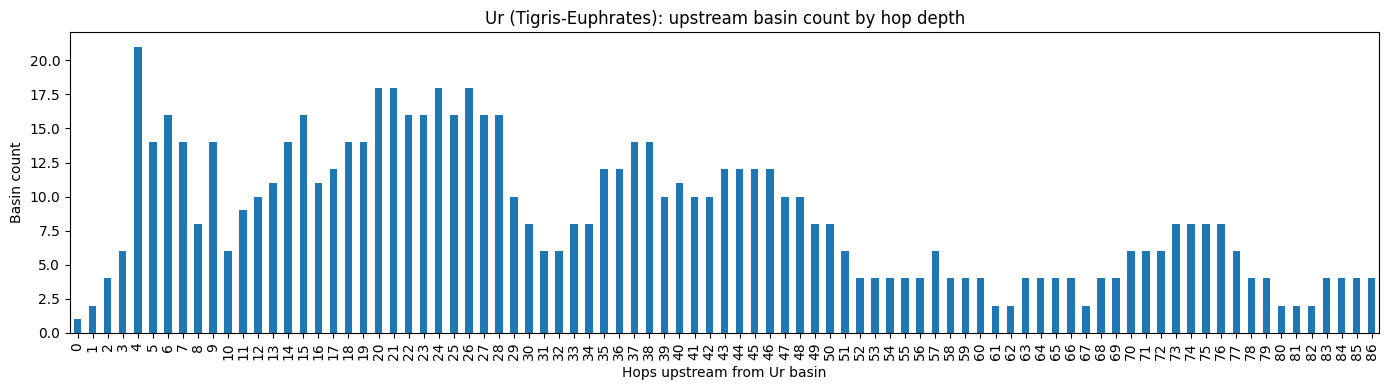

In [9]:
# Depth distribution — how many basins at each hop count?
ur_upstream['depth'].value_counts().sort_index().plot(
    kind='bar', figsize=(14, 4),
    title='Ur (Tigris-Euphrates): upstream basin count by hop depth',
    xlabel='Hops upstream from Ur basin', ylabel='Basin count'
)
plt.tight_layout()
plt.show()

## 4. dist_sink as metric distance proxy

For basins in the same watershed, `dist_sink` (distance to terminal outlet)
is pre-computed. The difference between an upstream basin's `dist_sink` and
the target basin's `dist_sink` gives approximate flow distance — without HydroRIVERS.

In [ ]:
# Scatter: hop depth vs. flow distance (km)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ur_upstream['depth'], ur_upstream['flow_dist_upstream_km'],
           alpha=0.15, s=5, color='steelblue')
ax.set_xlabel('Hop depth (next_down steps)')
ax.set_ylabel('Flow distance upstream (km, from dist_sink)')
ax.set_title('Hop depth vs. metric flow distance — Tigris-Euphrates catchment')
plt.tight_layout()
plt.show()

corr = ur_upstream[['depth','flow_dist_upstream_km']].corr().iloc[0,1]
print(f"Pearson correlation (depth vs flow_dist): {corr:.3f}")

## 5. Distance-decay weighting

Compare weighting schemes for upstream signature aggregation:
- **flat**: equal weight
- **area**: weighted by `sub_area` (larger basins count more)
- **decay_hop**: exponential decay over hop depth `exp(-λ × depth)`
- **decay_km**: exponential decay over flow distance `exp(-λ × dist_km)`
- **hydro_u**: HydroATLAS pre-computed upstream value (area-weighted, no distance decay)

In [ ]:
LAMBDA = 0.1  # decay parameter — tune later

df = ur_upstream.copy()
df['w_flat'] = 1.0
df['w_area'] = df['sub_area']
df['w_hop']  = np.exp(-LAMBDA * df['depth'])
df['w_km']   = np.exp(-LAMBDA * df['flow_dist_upstream_km'].clip(lower=0))

SIG_FIELDS = {
    'tmp_dc_syr': 'Temp local (\u00b0C\u00d710)',
    'pre_mm_syr': 'Precip local (mm/yr)',
    'ari_ix_sav': 'Aridity local',
}

rows = []
for field, label in SIG_FIELDS.items():
    u_field = field.replace('_syr','_uyr').replace('_sav','_uav')
    hydro_u = round(df[df['depth']==0][u_field].iloc[0], 1) if u_field in df.columns else None
    rows.append({
        'variable':  label,
        'flat':      round(weighted_sig(df, 'w_flat', field), 1),
        'area':      round(weighted_sig(df, 'w_area', field), 1),
        'decay_hop': round(weighted_sig(df, 'w_hop',  field), 1),
        'decay_km':  round(weighted_sig(df, 'w_km',   field), 1),
        'hydro_u':   hydro_u,
    })

pd.DataFrame(rows).set_index('variable')

## 6. Map the catchment

Use `next_sink` as a partition key to pull all basins in the macro-watershed,
coloured by `dist_sink` (distance to outlet) to show the drainage gradient.

In [ ]:
catchment_gdf = gpd.read_postgis(
    """
    SELECT hybas_id, dist_sink, sub_area, endo, order_, geom
    FROM basin08
    WHERE next_sink = %(sink)s
    """,
    conn, geom_col='geom', params={'sink': ur_next_sink}
)
print(f"Basins in macro-watershed (next_sink={ur_next_sink}): {len(catchment_gdf):,}")

fig, ax = plt.subplots(figsize=(12, 8))
catchment_gdf.plot(
    ax=ax, column='dist_sink', cmap='Blues_r',
    edgecolor='gray', linewidth=0.2, alpha=0.8,
    legend=True, legend_kwds={'label': 'dist_sink (km to outlet)'}
)
ax.set_title(f'Macro-watershed for Ur basin (next_sink={ur_next_sink})\n'
             f'{len(catchment_gdf):,} basins at level 08')
plt.tight_layout()
plt.show()

## 7. s/u variable audit

Confirm which variables have both local (`_s`) and upstream (`_u`) versions
and check how much they diverge for the Ur basin — large divergence =
the upstream/local contrast is environmentally meaningful here.

In [ ]:
ur_row = pd.read_sql(
    "SELECT * FROM basin08 WHERE hybas_id = %(hid)s",
    conn, params={'hid': ur_hybas}
).iloc[0]

cols = ur_row.index.tolist()
pairs = []
for c in cols:
    if '_s' in c:
        u_col = (c.replace('_syr','_uyr')
                  .replace('_sav','_uav')
                  .replace('_sse','_use')
                  .replace('_ssu','_usu'))
        if u_col in cols and u_col != c:
            s_val = ur_row[c]
            u_val = ur_row[u_col]
            if s_val and u_val and float(s_val) != 0:
                pairs.append({
                    'local_field':    c,
                    'upstream_field': u_col,
                    'local_val':      round(float(s_val), 2),
                    'upstream_val':   round(float(u_val), 2),
                    'pct_diff':       round(100 * (float(u_val) - float(s_val)) / abs(float(s_val)), 1),
                })

su_df = pd.DataFrame(pairs).set_index('local_field').sort_values('pct_diff', key=abs, ascending=False)
print(f"Variables with s/u pairs: {len(su_df)}")
su_df